# Import libraries

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import accuracy_score


## Load data

In [58]:
df = pd.read_csv('german_credit_data.csv',sep=',')

df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


## Explonatary data analysis

In [59]:
df.nunique()

Unnamed: 0          1000
Age                   53
Sex                    2
Job                    4
Housing                3
Saving accounts        4
Checking account       3
Credit amount        921
Duration              33
Purpose                8
Risk                   2
dtype: int64

In [60]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [61]:
df.dtypes

Unnamed: 0          int64
Age                 int64
Sex                   str
Job                 int64
Housing               str
Saving accounts       str
Checking account      str
Credit amount       int64
Duration            int64
Purpose               str
Risk                  str
dtype: object

In [62]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


Description of the dataset:
  - Average age is ~35, with most people between 27 and 42 (min: 19, max: 75). Typical ages for people that want to start a family.
  - The average loan amount is ~3,271 DM, with most loans ranging between 1,365 and 3,972 DM (min: 250, max: 18,424).
  - Most people need 1 to 2 years to pay the requested loan, with an average of 1 year and 8 months (min: 4 months, max: 6 years)

# Explonatary fairness analysis

In [63]:
df['Sex'].value_counts()


Sex
male      690
female    310
Name: count, dtype: int64

Text(0.5, 1.0, 'Gender')

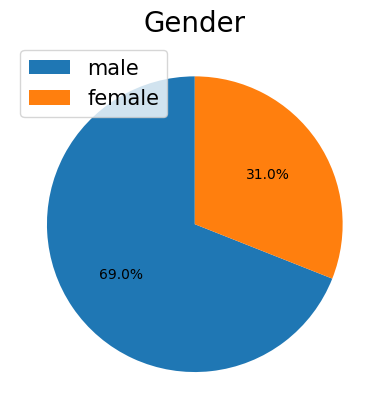

In [64]:
#Get population count by race

counts = df['Sex'].value_counts()
labels = counts.index

#Plot pie chart
plt.pie(counts, startangle=90, autopct='%1.1f%%')
plt.legend(labels, loc=2, fontsize=15)
plt.title("Gender", size=20)

In [65]:
df['y'] = [1 if y == 'good'else 0 for y in df['Risk']]

prev = df['y'].mean()
prev_sex = df.groupby('Sex')['y'].mean()
diff = (prev_sex['male'] - prev_sex['female'])*100

print(f'Males: {prev_sex['male'] *100:.2f}%')
print(f'Females: {prev_sex['female'] *100:.2f}%')
print()
print('Interpretation:')
print(f'Males are {diff:.2f}% more likely to receive a loan than females')


Males: 72.32%
Females: 64.84%

Interpretation:
Males are 7.48% more likely to receive a loan than females


The dataset itself has unequal distributions between groups -> worth investigating for fairness.

## Preprocess dataset

In [66]:
feature_names = [
    'Age',
    'Sex',              
    'Job',              # Job of the person. (0 —> Unskilled + Non-Resident, 1 —> Unskilled + Resident, 2 —> Skilled, 3 —> Highly Skilled)
    'Housing',          # Housing status (rent, lives for free, owning)
    'Saving accounts',  # Long-term savings category
    'Checking account', # Current money level category
    'Credit amount',    # Requested loan size
    'Duration',         # Loan duration (months)
    'Purpose'           # Reason for loan
]
target_name = 'Risk' # if its risky giving a loan or not

def data_processing(data, features, target_name:str):
    df = data
    df = df[df['Job'] != 0]
    ### Groups of interest
    df['Sex'] = df['Sex'].map({'male': 1, 'female': 2})
    sex = df["Sex"].values

    ### Target
    df["target"] = df[target_name] == 'good'
    target = df["target"].values    
    df = df[features + ["target", target_name]] ##we want to keep df before one_hot encoding to make Bias Analysis
    df_processed = df[features].copy()
    cols_without_nulls = [ "Job", "Housing", "Purpose", "Sex"]
    cols_with_nulls = ['Saving accounts', 'Checking account']
    df_processed = pd.get_dummies(df_processed, prefix=None, prefix_sep='_', dummy_na=False, columns=cols_without_nulls, drop_first=True)
    df_processed = pd.get_dummies(df_processed, prefix=None, prefix_sep='_', dummy_na=True, columns=cols_with_nulls, drop_first=True)
    return df_processed, df, target, sex

data, data_original, target, group = data_processing(df, feature_names, target_name)

X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    data, target, group, test_size=0.2, random_state=0)

In [67]:
data_original

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,target,Risk
0,67,1,2,own,NaN,little,1169,6,radio/TV,True,good
1,22,2,2,own,little,moderate,5951,48,radio/TV,False,bad
2,49,1,1,own,little,NaN,2096,12,education,True,good
3,45,1,2,free,little,little,7882,42,furniture/equipment,True,good
4,53,1,2,free,little,little,4870,24,car,False,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,31,2,1,own,little,NaN,1736,12,furniture/equipment,True,good
996,40,1,3,own,little,little,3857,30,car,True,good
997,38,1,2,own,little,NaN,804,12,radio/TV,True,good
998,23,1,2,free,little,little,1845,45,radio/TV,False,bad


In [68]:
data

,Age,Credit amount,Duration,Job_2,Job_3,Housing_own,Housing_rent,Purpose_car,Purpose_domestic appliances,Purpose_education,...,Purpose_repairs,Purpose_vacation/others,Sex_2,Saving accounts_moderate,Saving accounts_quite rich,Saving accounts_rich,Saving accounts_nan,Checking account_moderate,Checking account_rich,Checking account_nan
0,67,1169,6,True,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,22,5951,48,True,False,True,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
2,49,2096,12,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
3,45,7882,42,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,53,4870,24,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31,1736,12,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
996,40,3857,30,False,True,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
997,38,804,12,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
998,23,1845,45,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [69]:
data.columns

Index(['Age', 'Credit amount', 'Duration', 'Job_2', 'Job_3', 'Housing_own',
       'Housing_rent', 'Purpose_car', 'Purpose_domestic appliances',
       'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV',
       'Purpose_repairs', 'Purpose_vacation/others', 'Sex_2',
       'Saving accounts_moderate', 'Saving accounts_quite rich',
       'Saving accounts_rich', 'Saving accounts_nan',
       'Checking account_moderate', 'Checking account_rich',
       'Checking account_nan'],
      dtype='str')

In [70]:
data_scaled = data.copy()
cols = ['Age', 'Credit amount', 'Duration']
scaler = StandardScaler()
data_scaled[cols] = scaler.fit_transform(data_scaled[cols])
data_scaled

,Age,Credit amount,Duration,Job_2,Job_3,Housing_own,Housing_rent,Purpose_car,Purpose_domestic appliances,Purpose_education,...,Purpose_repairs,Purpose_vacation/others,Sex_2,Saving accounts_moderate,Saving accounts_quite rich,Saving accounts_rich,Saving accounts_nan,Checking account_moderate,Checking account_rich,Checking account_nan
0,2.823383,-0.751354,-1.242677,True,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,-1.202833,0.948181,2.240855,True,False,True,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
2,1.212897,-0.421896,-0.745029,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
3,0.855011,1.634463,1.743208,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1.570783,0.563991,0.250265,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.397590,-0.549841,-0.745029,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
996,0.407653,0.203968,0.747913,False,True,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
997,0.228710,-0.881076,-0.745029,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
998,-1.113362,-0.511102,1.992031,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Scale data (logistic regression)

In [71]:
X_train_lr = X_train.copy()
X_test_lr = X_test.copy()


cols = ['Age', 'Credit amount', 'Duration']
scaler = StandardScaler()
X_train_lr[cols] = scaler.fit_transform(X_train_lr[cols])
X_test_lr[cols] = scaler.transform(X_test_lr[cols])

## Train white and black box models without any processing

In [72]:
data_original['target'].value_counts(normalize=True)

target
True     0.700409
False    0.299591
Name: proportion, dtype: float64

The dataset is imbalanced, with 70% “good” cases and 30% “bad” cases. Therefore, using balanced accuracy is more appropriate, as it accounts for performance on both classes equally.

In [73]:
# Logistic Regression (white-box)
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_lr, y_train)
lr_preds = lr_model.predict(X_test_lr)

# Random Forest (black-box)
rf_model = RandomForestClassifier(n_estimators=100, random_state=0)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Compute balanced accuracy scores
lr_b_acc = balanced_accuracy_score(y_test, lr_preds)
rf_b_acc = balanced_accuracy_score(y_test, rf_preds)

print(f"Logistic Regression Balanced Accuracy: {lr_b_acc:.4f}")
print(f"Random Forest Balanced Accuracy:      {rf_b_acc:.4f}")

Logistic Regression Balanced Accuracy: 0.5961
Random Forest Balanced Accuracy:      0.6044


### Check fairness metrics (Statistical parity and Equalized odds) before post processing

Logistic Regression → SP: 0.055972013993003555, TPR: 0.05906264945002382, FPR: 0.0702614379084967
Random Forest → SP: 0.05472263868065963, TPR: 0.020086083213773365, FPR: 0.22058823529411764


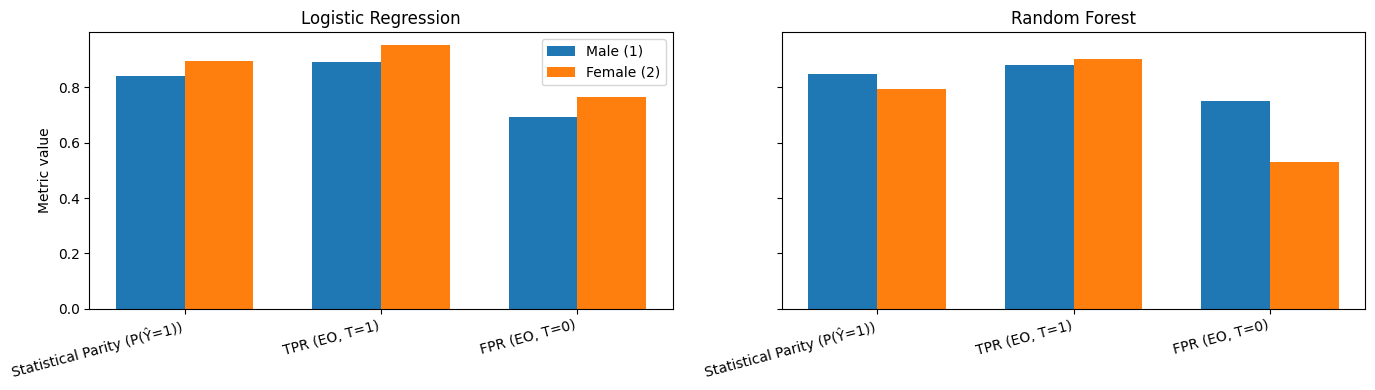

In [74]:
def safe_rate(numerator, denominator):
    return numerator / denominator if denominator != 0 else np.nan


def compute_fairness_metrics(y_true, y_pred, groups):
    results = {}
    for g in np.unique(groups):
        mask = (groups == g)
        y_g = y_true[mask]
        pred_g = y_pred[mask]

        sp = np.mean(pred_g)  # P(Ŷ=1 | G=g)

        tp = np.sum((pred_g == 1) & (y_g == 1))
        fn = np.sum((pred_g == 0) & (y_g == 1))
        fp = np.sum((pred_g == 1) & (y_g == 0))
        tn = np.sum((pred_g == 0) & (y_g == 0))

        tpr = safe_rate(tp, tp + fn)  # EO(T=1)
        fpr = safe_rate(fp, fp + tn)  # EO(T=0)

        results[int(g)] = {
            "SP": float(sp),
            "TPR": float(tpr) if not np.isnan(tpr) else np.nan,
            "FPR": float(fpr) if not np.isnan(fpr) else np.nan
        }
    return results


lr_metrics = compute_fairness_metrics(y_test, lr_preds, group_test)
rf_metrics = compute_fairness_metrics(y_test, rf_preds, group_test)

def plot_fairness_combined(lr_metrics, rf_metrics):
    labels = ["Statistical Parity (P(Ŷ=1))", "TPR (EO, T=1)", "FPR (EO, T=0)"]
    x = np.arange(len(labels))
    width = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

    for ax, metrics, title in zip(
        axes,
        [lr_metrics, rf_metrics],
        ["Logistic Regression", "Random Forest"]
    ):
        male = [metrics[1]["SP"], metrics[1]["TPR"], metrics[1]["FPR"]]
        female = [metrics[2]["SP"], metrics[2]["TPR"], metrics[2]["FPR"]]

        sp_diff = abs(metrics[1]["SP"] - metrics[2]["SP"])
        tpr_diff = abs(metrics[1]["TPR"] - metrics[2]["TPR"])
        fpr_diff = abs(metrics[1]["FPR"] - metrics[2]["FPR"])

        print(f"{title} → SP: {sp_diff}, TPR: {tpr_diff}, FPR: {fpr_diff}")

        ax.bar(x - width/2, male, width, label="Male (1)")
        ax.bar(x + width/2, female, width, label="Female (2)")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=15, ha="right")
        ax.set_title(title)

    axes[0].set_ylabel("Metric value")
    axes[0].legend()

    plt.tight_layout()
    plt.show()


plot_fairness_combined(lr_metrics, rf_metrics)

## Accuracy per group

In [75]:
men_idx = group_test == 1

# Women
women_idx = group_test == 2

lr_m_acc = balanced_accuracy_score(y_test[men_idx], lr_preds[men_idx])
lr_w_acc = balanced_accuracy_score(y_test[women_idx], lr_preds[women_idx])


rf_m_acc = balanced_accuracy_score(y_test[men_idx], rf_preds[men_idx])
rf_w_acc = balanced_accuracy_score(y_test[women_idx], rf_preds[women_idx])

print("LR Accuracy (Men):", lr_m_acc)
print("LR Accuracy (Women):", lr_w_acc)

print("RF Accuracy (Men):", rf_m_acc)
print("RF Accuracy (Women):", rf_w_acc)

LR Accuracy (Men): 0.5988562091503269
LR Accuracy (Women): 0.5932568149210904
RF Accuracy (Men): 0.5661764705882353
RF Accuracy (Women): 0.6865136298421808
